In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pbn_37k
from pbn_37k.ask import sigAssistant

import pandas as pd
from tqdm import tqdm
tqdm.pandas()

from dotenv import load_dotenv
load_dotenv()

brain = sigAssistant(pathCache=".cache/", llm_highend="gpt-4o",  llm_fast="gpt-4o-mini")

/home/kelu/projets/maptivity/.venv/lib/python3.11/site-packages/langchain/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


In [3]:
with open("data/cities/prompt/prompt.md", "r") as f:
    prompt_template = f.read()
with open("data/cities/activities.md", "r") as f:
    prompt_activity = f.read()
with open("data/cities/portfolio.md", "r") as f:
    prompt_portfolio = f.read()
with open("data/cities/prompt/cities.md", "r") as f:
    cities = [x.strip("*").strip() for x in f.read().split("\n") if len(x.strip("*").strip())]
cn = ["gotham", "baraddur", "kingslanding", "coruscant", "wakanda", "shire", "capitol", "kakariko", "hogsmeade"]
assert len(cn) == len(cities)

In [4]:
HEADER = """---
layout: default
title: TITLE
parent: PARENT
has_children: true
nav_order: NAVORDER
---\n\n"""

In [5]:
CITIES = {}
VISIONS = []
ACTIVITIES = []

for i in range(len(cities)):
    desc = cities[i]
    print(cn[i])
    q = prompt_template.replace("$CITYNAME$", desc)
    urban_report = brain.ask(q)
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    

    analysis = brain.analyseText( txt=urban_report,
            TypeOfItem = "Vision",
            Source="maptivity.online",
            Place=cn[i].title(),
            MIN=15,
            Reviewed=True,
            MODEL="gpt-4o-mini")
        
    CITIES[cn[i]] = {"report": urban_report}
    VISIONS.append(urban_report)

    report = HEADER.replace("TITLE", cn[i].title()).replace("NAVORDER", str(i+3)).replace("\nparent: PARENT","") + "![](places/"+cn[i]+".png)\n\n" + urban_report
    report = report.replace("## **Overview & Sustainability Profile**","## Overview & Sustainability Profile")
    SCORE = "\n\n### ISO37101 mapping for '"+analysis.Source_Title.unique()[0]+"'\n\n#### Scores\n\n" + analysis[["Score","Purpose","Issue","Justification"]].to_markdown(index=False)+"\n\n"
    report = report + SCORE
    
    with open(f"docs/{cn[i]}_report.md", "w") as f:
        f.write(report)

gotham
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
baraddur
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
kingslanding
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
coruscant
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
wakanda
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
shire
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
capitol
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
kakariko
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done
hogsmeade
--- gpt-4o-mini:	 2025-10-24 15:48:09
Already done


In [7]:
for i in range(len(cities)):
    desc = CITIES[cn[i]]["report"]
    q = prompt_portfolio.replace("DESCRIPTION", desc)
    urban_report = brain.ask(q)

    
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    urban_report = "![](images/"+cn[i]+"_review.png)\n\n" + urban_report
    report = HEADER.replace("TITLE", cn[i].title()+"'s portfolio").replace("NAVORDER", "1").replace("PARENT",cn[i].title()) + urban_report
    CITIES[cn[i]]["portfolio"] = {"portfolio": report}
    with open(f"docs/{cn[i]}_portfolio.md", "w") as f:
        f.write(report)

    for k in range(7):
        q = prompt_activity.replace("$$DESC$$", desc).replace("$$ACT$$", urban_report)
        q = q.replace("$$NN$$ ", str(k+1))
        activity_report = brain.ask(q)
        ACTIVITIES.append(activity_report)
        CITIES[cn[i]]["portfolio"][f"activity_{k+1}"] = activity_report
        analysis = brain.analyseText( txt=activity_report,
                        TypeOfItem = "Activity",
                        Source="maptivity.online",
                        Place=cn[i].title(),
                        MIN=7,
                        Reviewed=False,
                        MODEL="gpt-4o-mini")

        reportB = activity_report


        SCORE = "\n\n### ISO37101 mapping for '"+analysis.Source_Title.unique()[0]+"'\n\n#### Scores\n\n" + analysis[["Score","Purpose","Issue","Justification"]].to_markdown(index=False)+"\n\n"

        reportB = reportB.replace("## **CONTEXTUAL FOUNDATION**",SCORE + "## **CONTEXTUAL FOUNDATION**")
        shorttitle = reportB.split("###")[1].split("\n")[1].replace("**","").split(":")[0].strip().replace('"','').replace("/","-")
        print(cn[i], k+1, shorttitle)
        reportB = HEADER.replace("TITLE", shorttitle).replace("NAVORDER", str(k+2)).replace("PARENT",cn[i].title()) + reportB
        reportB = reportB.replace("has_children: true _n","")


        with open(f"docs/{cn[i]}_activity_{k+1}.md", "w") as f:
            f.write(reportB)

--- gpt-4o-mini:	 2025-10-24 15:48:34
--- gpt-4o-mini:	 2025-10-24 15:48:58
Old MIN: 7
New MIN: 7
--- Function call:	 2025-10-24 15:49:12
--- gpt-4o-mini:	 2025-10-24 15:49:13
--- gpt-4o-mini:	 2025-10-24 15:49:16
--- gpt-4o-mini:	 2025-10-24 15:49:17
--- gpt-4o-mini:	 2025-10-24 15:49:18
--- gpt-4o-mini:	 2025-10-24 15:49:19
--- gpt-4o-mini:	 2025-10-24 15:49:20
--- gpt-4o-mini:	 2025-10-24 15:49:21
--- gpt-4o-mini:	 2025-10-24 15:49:24
--- gpt-4o-mini:	 2025-10-24 15:49:25
--- gpt-4o-mini:	 2025-10-24 15:49:25
--- gpt-4o-mini:	 2025-10-24 15:49:25
--- gpt-4o-mini:	 2025-10-24 15:49:25
--- gpt-4o-mini:	 2025-10-24 15:49:25
--- gpt-4o-mini:	 2025-10-24 15:49:25
--- gpt-4o-mini:	 2025-10-24 15:49:25
--- gpt-4o-mini:	 2025-10-24 15:49:25
Good du premier coup, length 8 vs MIN of 7
gotham 1 Gotham Waterfront Resilience Park
--- gpt-4o-mini:	 2025-10-24 15:49:51
Old MIN: 7
New MIN: 7
--- Function call:	 2025-10-24 15:50:06
--- gpt-4o-mini:	 2025-10-24 15:50:08
--- gpt-4o-mini:	 2025-10-24 1

# Reviews

In [8]:
import pbn_37k.img as iImg

df = brain.getMemory()
df = df[df.Source.isin(ACTIVITIES+VISIONS)]
print(len(df))
df.head(2)
df.Scale = df.Scale.str.strip().str.capitalize()
df.Scale = df.Scale.apply(lambda x: x.replace("Neighborhood","Neighbourhood").replace("City-wide","Neighbourhood"))
df.Scale = df.Scale.apply(lambda x: x.replace("District","Neighbourhood").replace("City","Neighbourhood"))
df.Scale = df.Scale.apply(lambda x: x.replace("Hyperlocal","Building"))
df.Scale.unique()

737


array(['Neighbourhood', 'Building'], dtype=object)

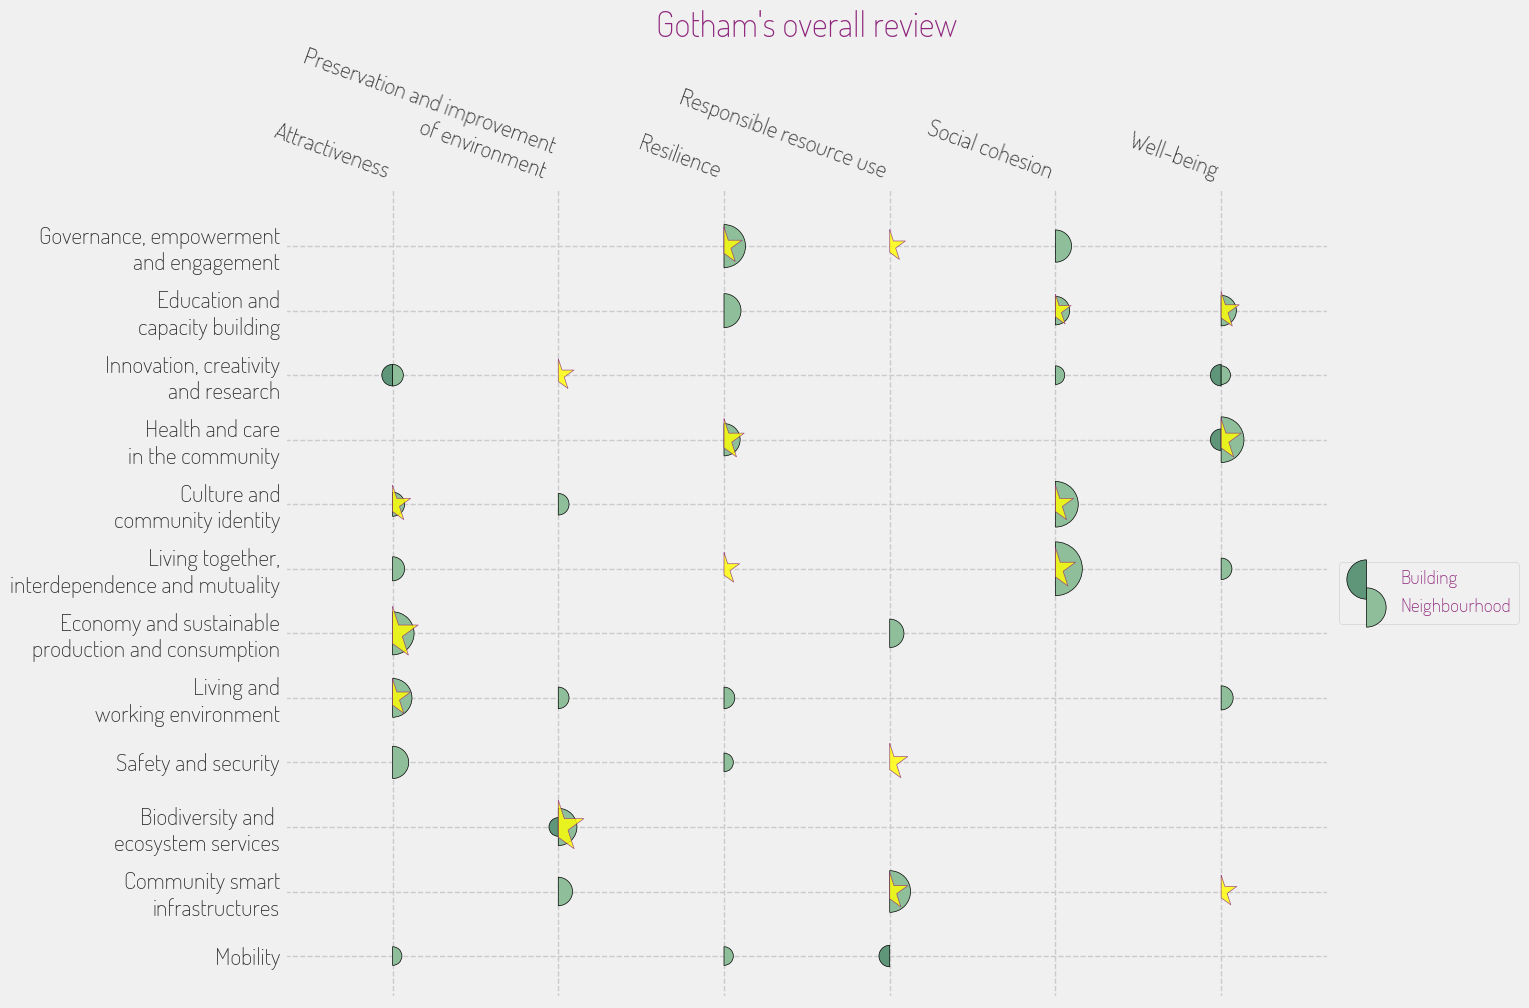

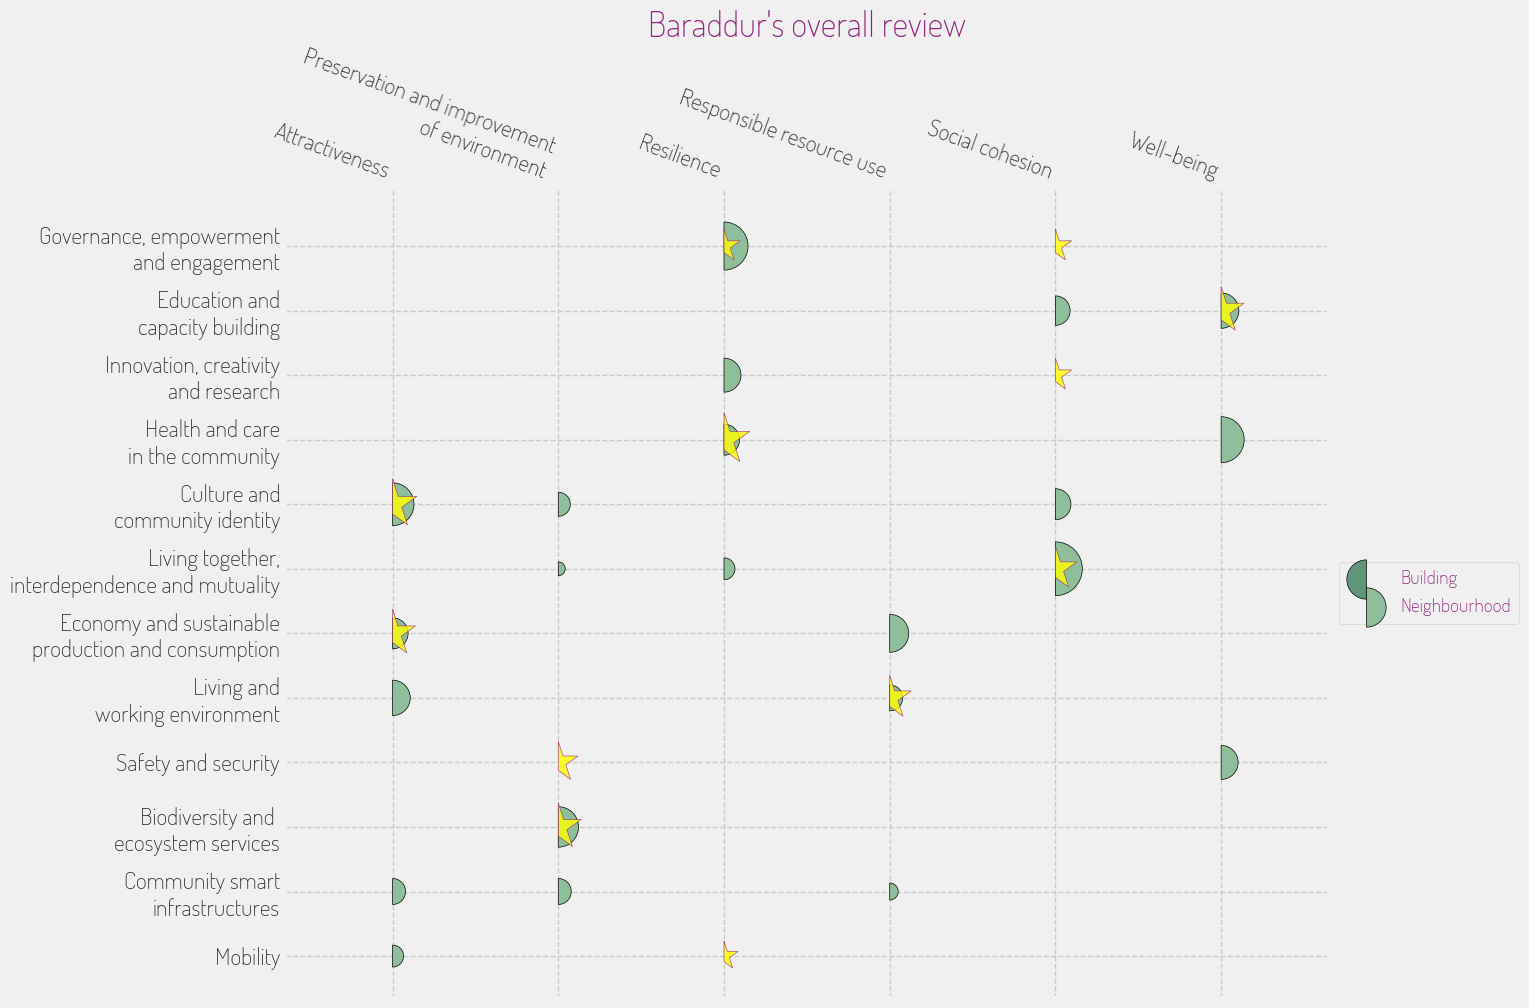

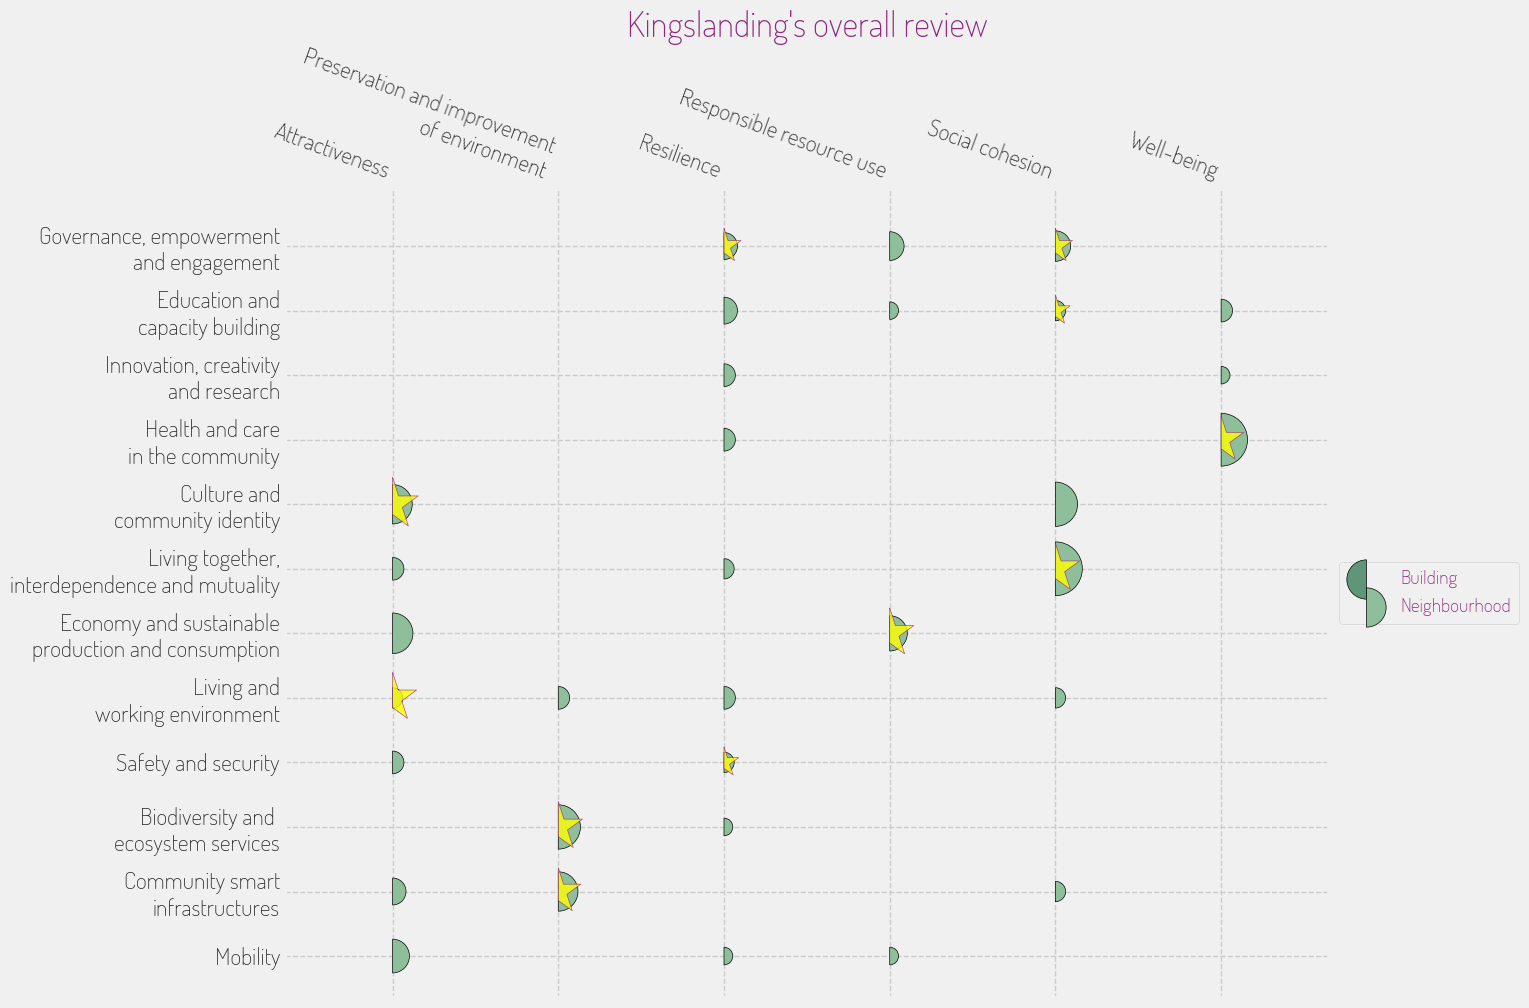

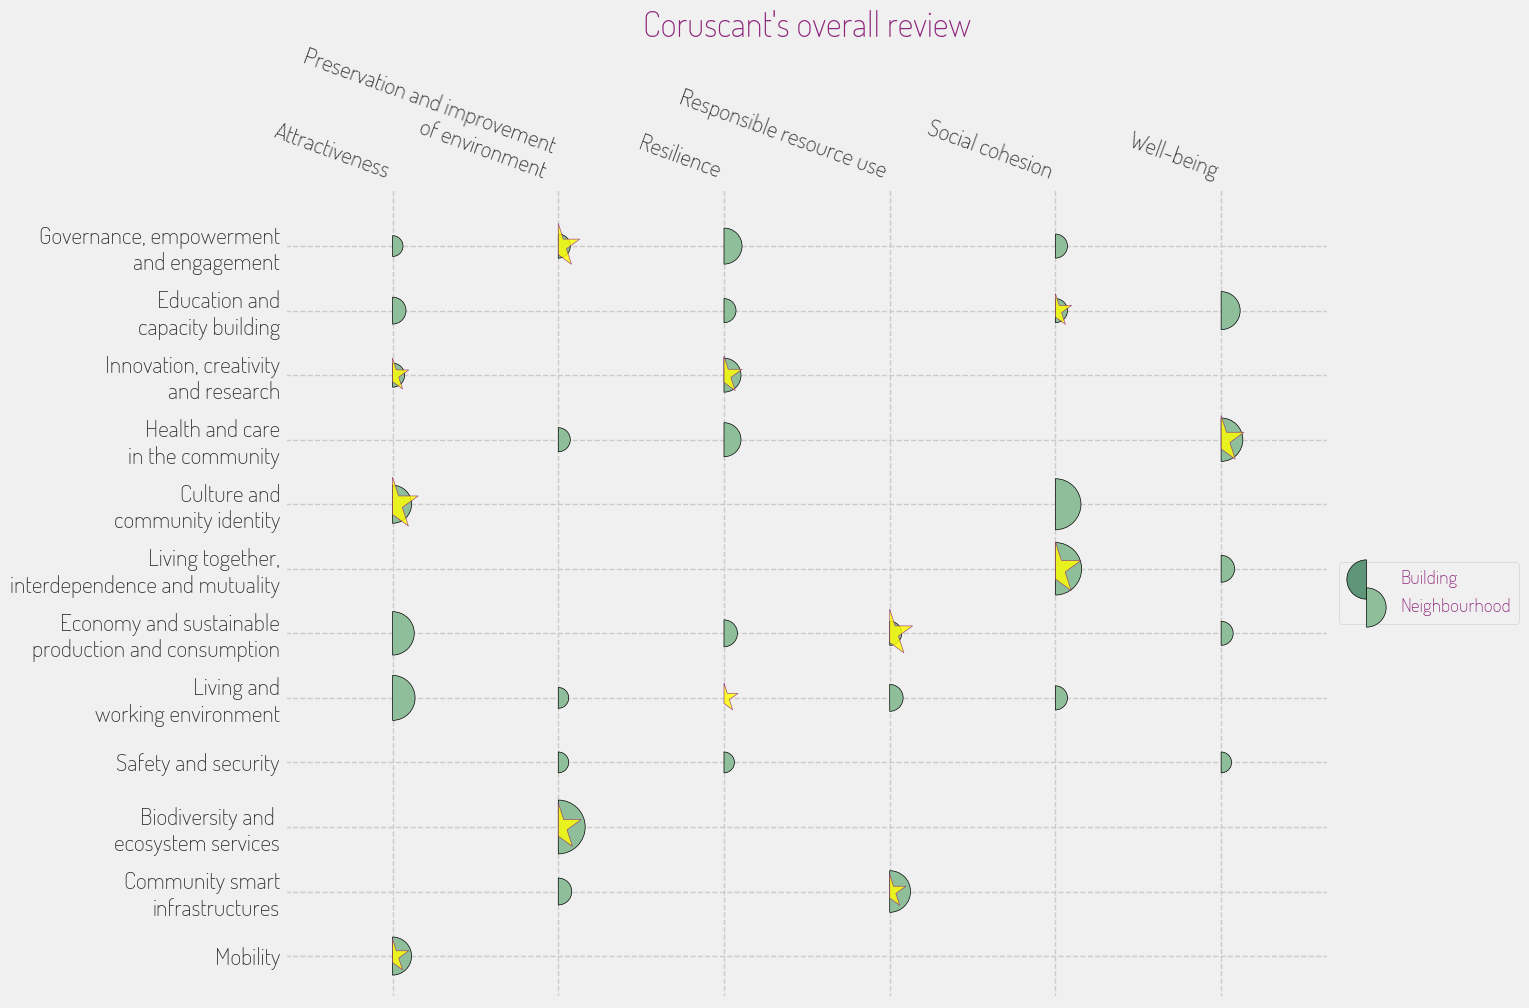

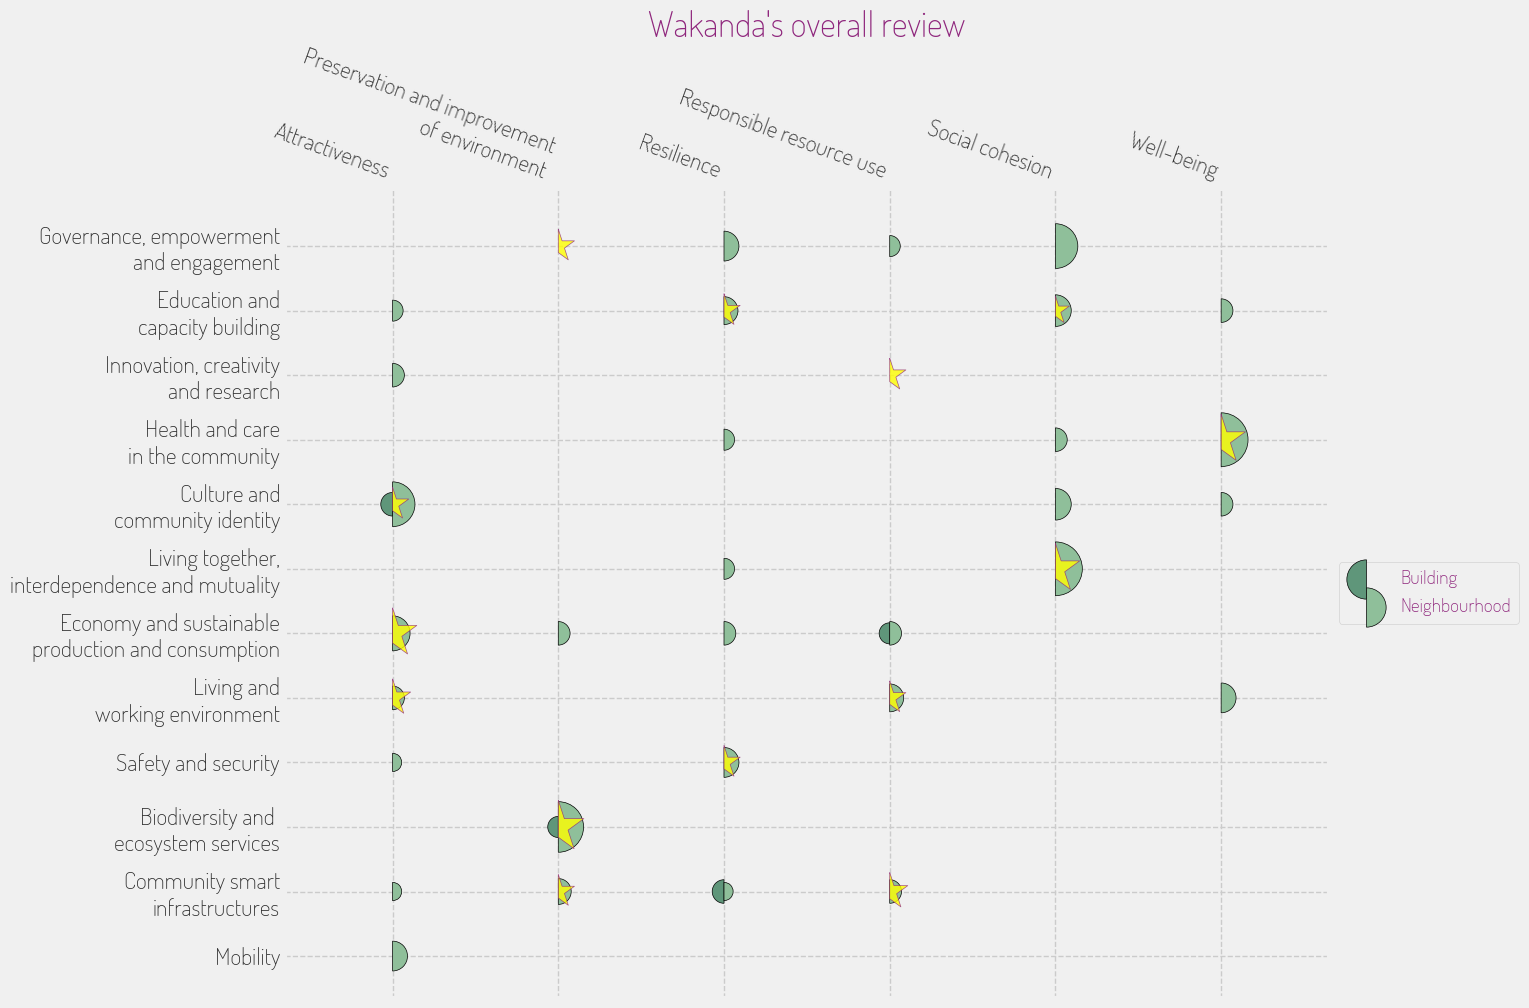

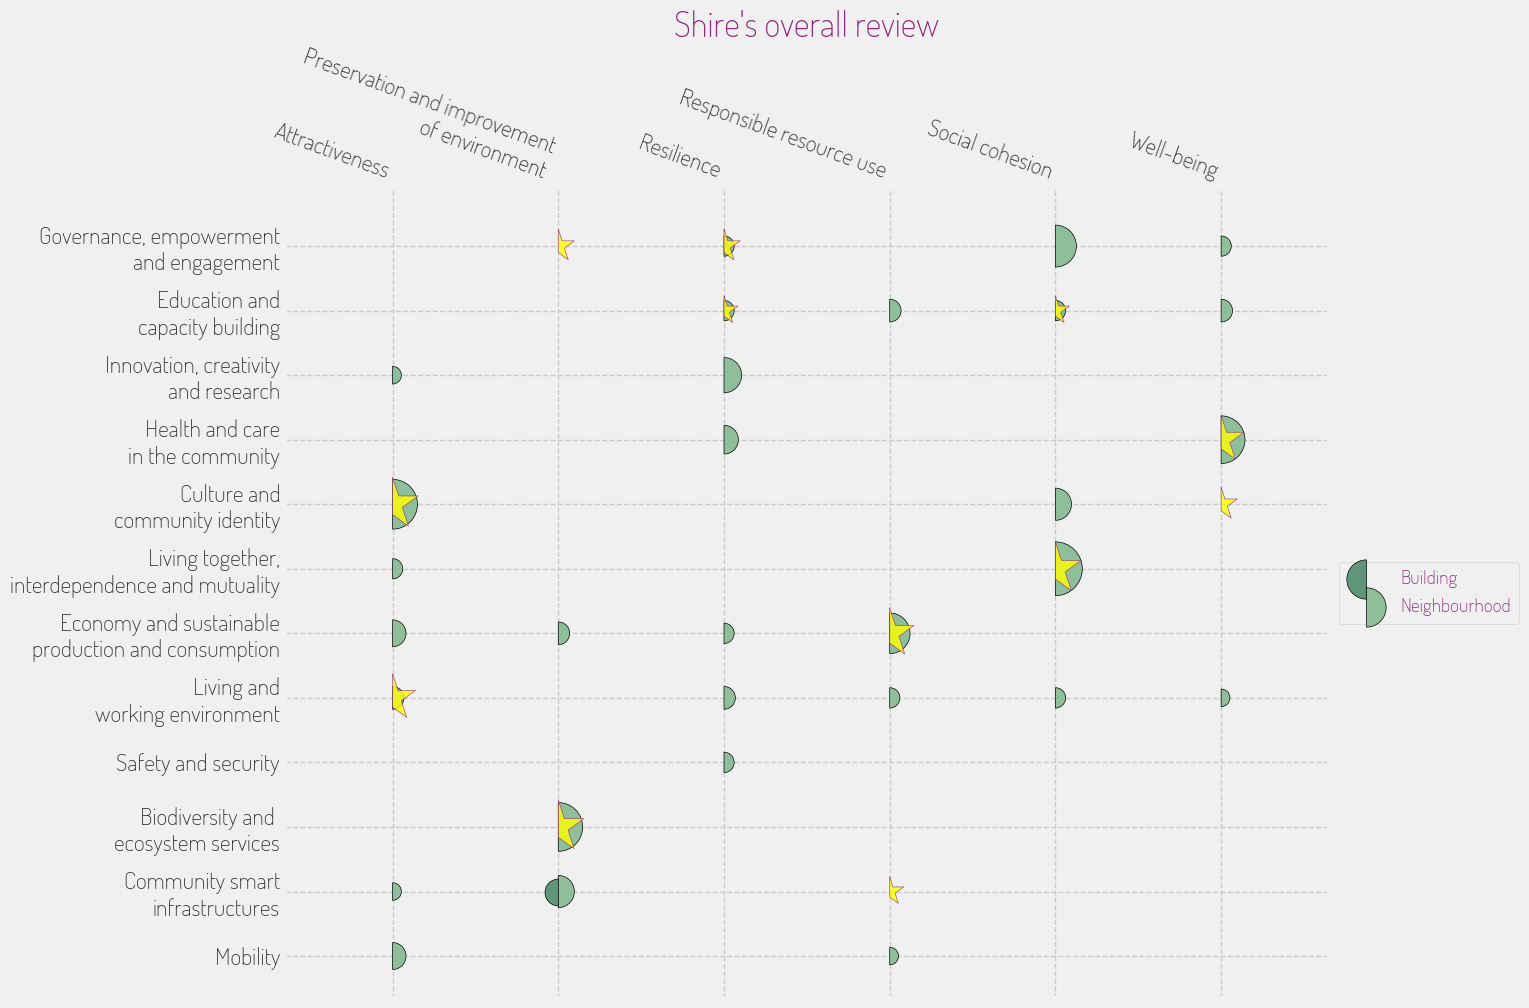

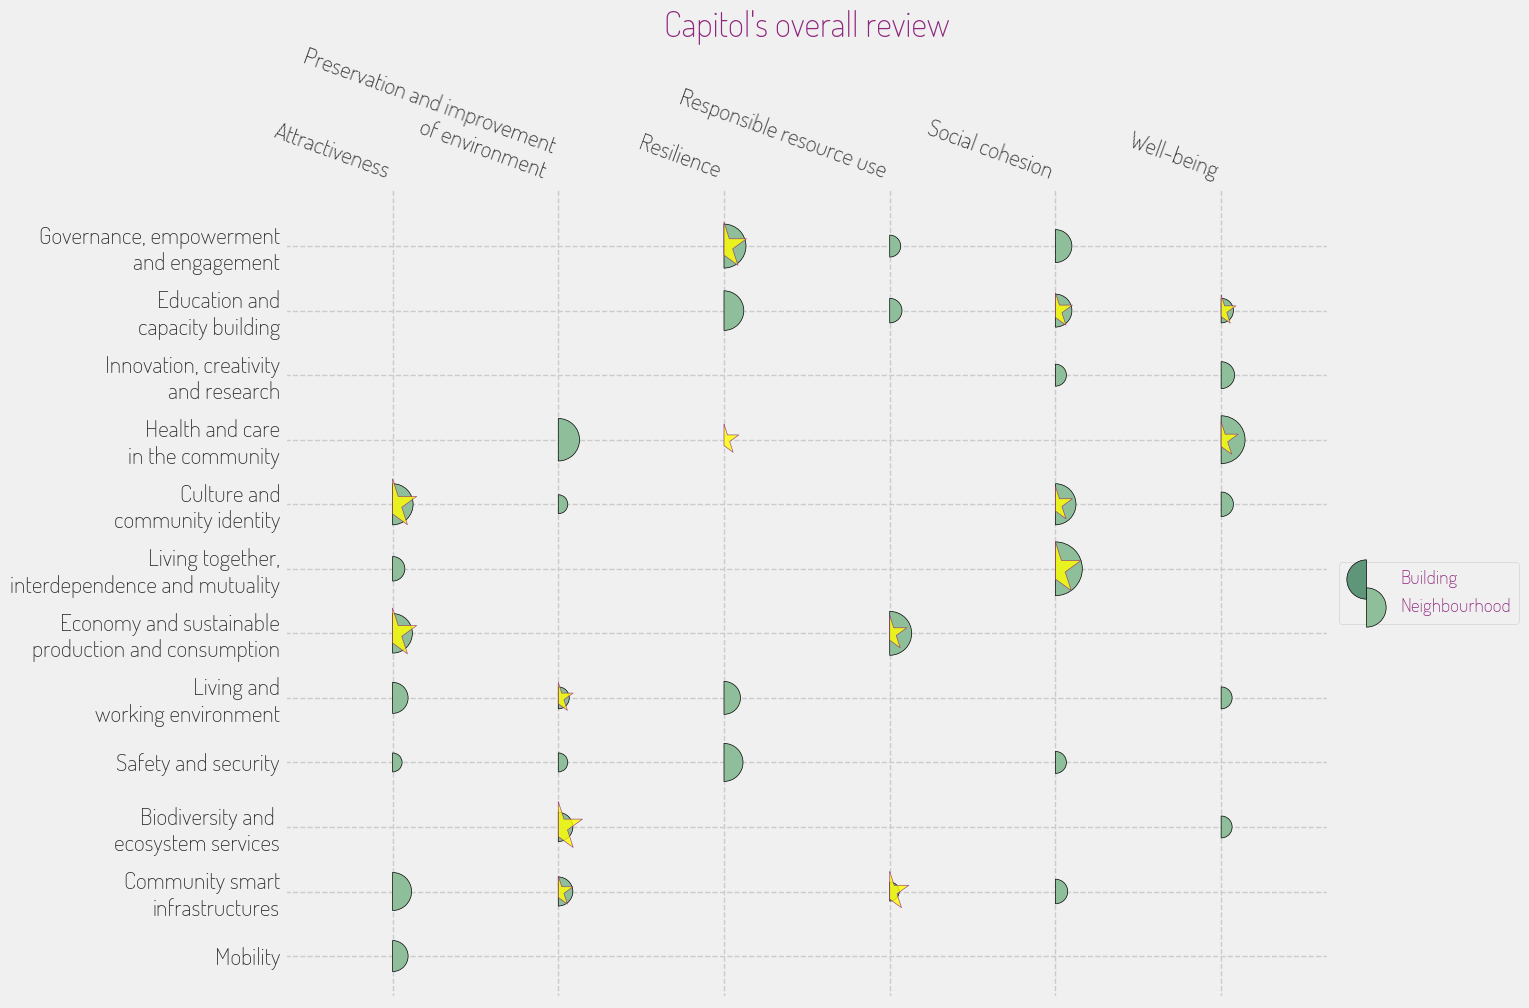

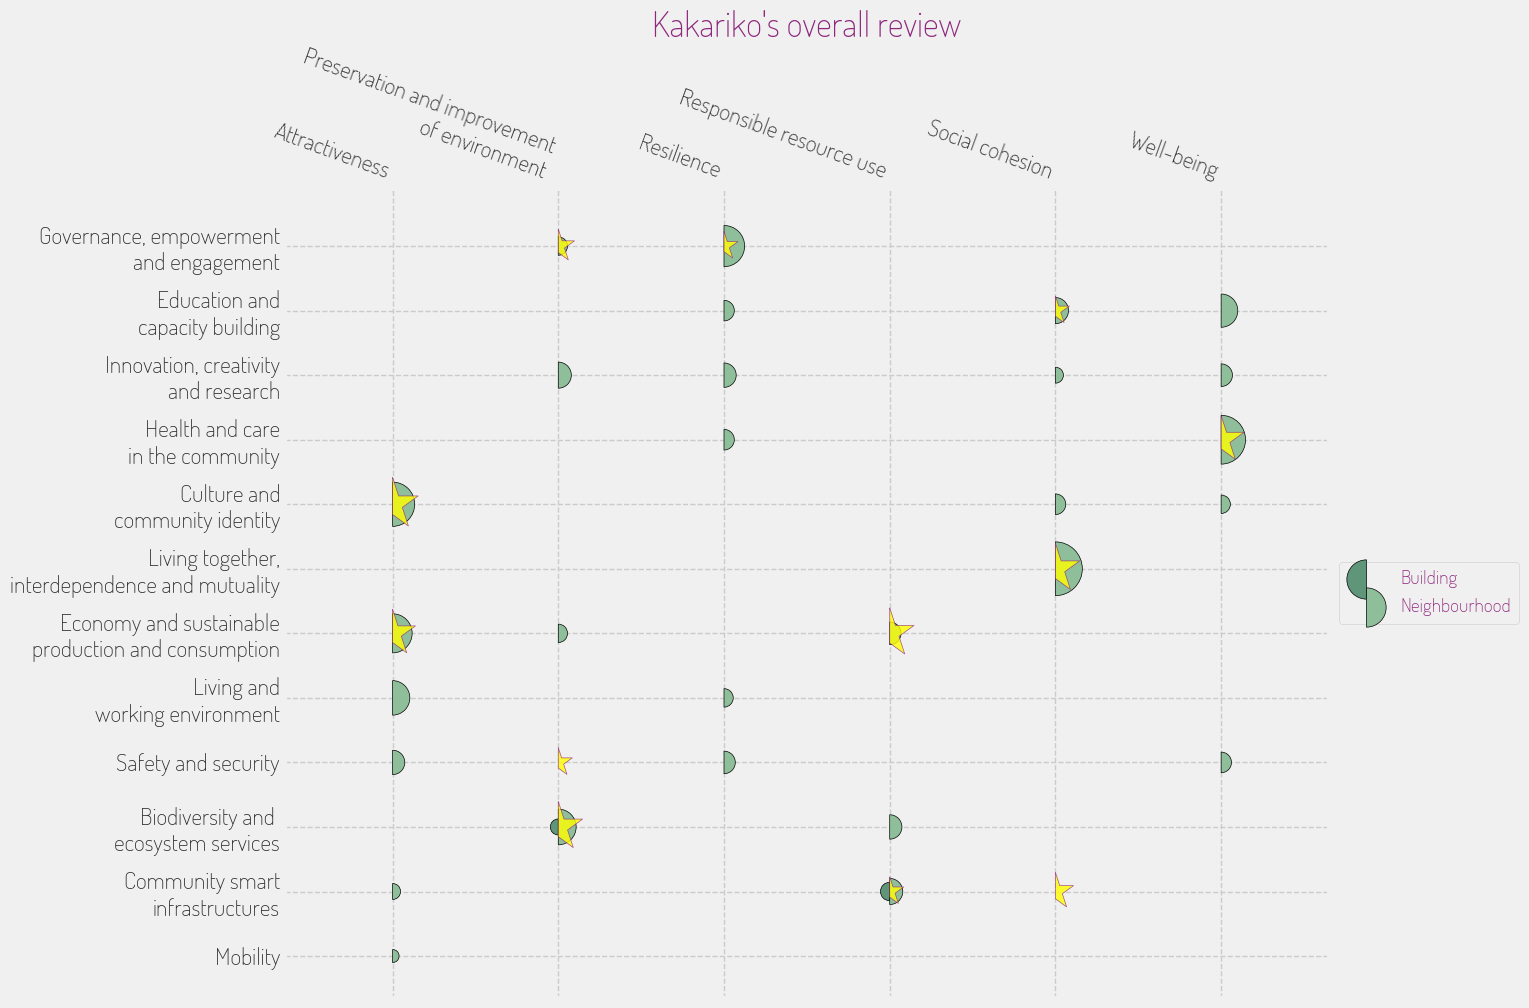

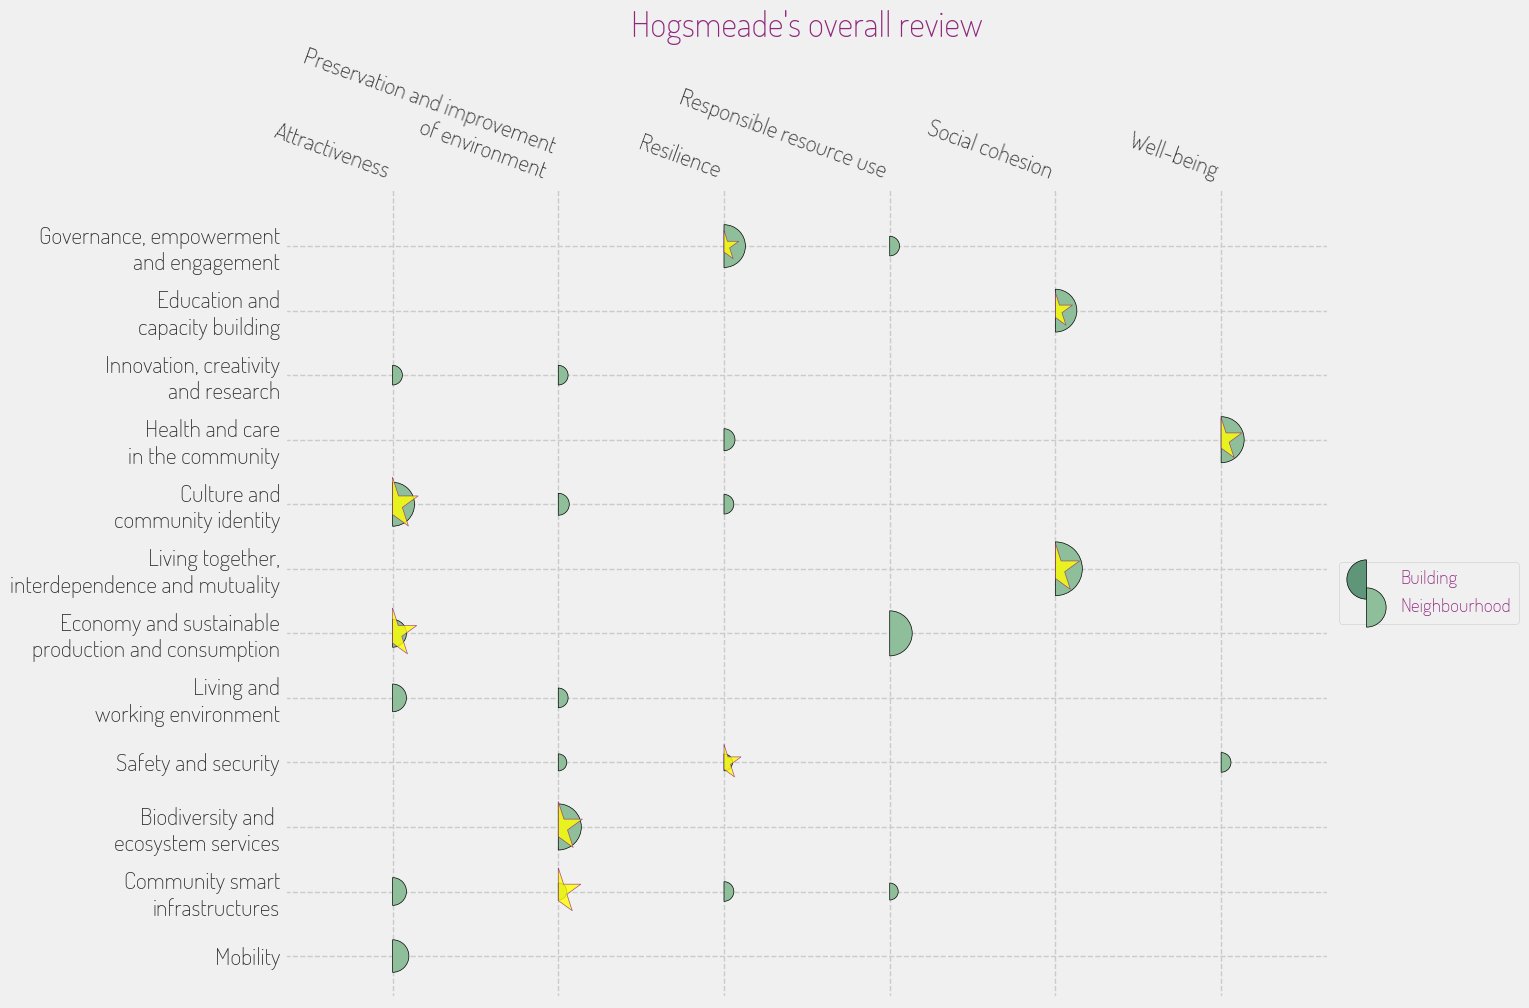

In [9]:
for place in df.Place.unique():
    D = df[df.Place == place]
    dfRef = D[D.Type == "Vision"]
    dfUC  = D[D.Type == "Activity"]
    plt, ax = iImg.createImg(dfUC, dfRef, title=place+"'s overall review")
    plt.savefig("docs/images/"+place.lower()+"_review.png",  bbox_inches="tight")

# Definitions

In [10]:
with open(pbn_37k.dbkg.path_to_defs, "r") as f:
    defs = f.read().split("\n#")

DEFS = "## Definitions\n\nTo help with the Placemaking Maptivity, it helps to understand some key definitions that represent the game area.\n\n" 

P = [x[6:].strip() for  x in defs[2:8]]
I = [x[6:].strip() for  x in defs[9:-1]]+[defs[-1].split("\n\n")[0]]
DEFS += "\n\n### Issues\n\n"
for i in I:
    a, b  = i.split("\n",1)
    x = brain.ask("Define the following ISO37101 Issue: " + a + "\n\nIt is described as : " + b +"\n\nWrite a paragraph that a teenager would understand, but also in a business appropriate manner for stakeholder engagement. Start your answer with '**"+a+"** is defined as '..." )
    DEFS += " * "+x +"\n"
DEFS += "\n\n### Purposes\n\n"
for i in P:
    a, b  = i.split("\n",1)
    x = brain.ask("Define the following ISO37101 Purpose: " + a + "\n\nIt is described as : " + b +"\n\nWrite a paragraph that a teenager would understand, but also in a business appropriate manner for stakeholder engagement. Start your answer with '**"+a+"** is defined as '..." )
    DEFS += " * "+x +"\n"

--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53
--- gpt-4o-mini:	 2025-10-24 16:52:53


In [11]:
HH = """---
layout: default
title: The PlaceMaking Maptivity
nav_order: 1
---

"""

In [12]:
example = """

## An example

Following a game session, people will have place activitie and visions for their neighbourhoods. Here is an example of a report that could be generated automatically to summarize the outcomes of the session.

![](images/gotham_review.png)

On this map, **stars** represent the Vision of the Place, and Circles represent Activities proposed to improve the sustainability of the neighbourhood.

A star aligned with a circle means that the activity contributes to achieving the vision.  When there's a circle but no star, it means the activity is beneficial but not directly linked to a specific vision.
Conversely, a star without a circle indicates a vision that currently lacks a supporting activity.


"""

In [13]:
with open("data/description.md", "r") as f:
    t = f.read()
with open("docs/index.md", "w") as f:
    f.write(HH + t + example + DEFS)


# Finding recommendations  ****@TODO

In [14]:
def findAction(target,catalogue,n=3):
    results = []
    target["combo"] = target["Purpose"]+"-"+target["Issue"]+"-"+target["Scale"]
    catalogue["combo"] = catalogue["Purpose"]+"-"+catalogue["Issue"]+"-"+catalogue["Scale"]
    while len(results) < n:
        # Let's start
        for ix, row in target.iterrows():
            X, Y, Z, S = row["Purpose"],row["Issue"], row["Scale"], row["Score"]
            sl = catalogue[(catalogue.Purpose == X) & (catalogue.Issue == Y)][["Source_Title","Purpose","Issue","Scale","Score","combo"]]
            sl["mult"] = sl.Scale.apply(lambda x: 5 if x == row["Scale"] else 1)
            sl["fScore"] = sl.Score * sl.mult * S
        choice = pd.pivot_table(sl, values='fScore', index='Source_Title',aggfunc='sum').sort_values(by="fScore", ascending=False).reset_index().iloc[0]
        results.append(choice["Source_Title"])
        # Now removing the points ticked
        #print(choice)
        thechoice = list(catalogue[catalogue.Source_Title == choice.Source_Title].combo)
        target = target[~(target.combo.isin(thechoice))]
        #print(thechoice)
        # Now removing the possible from the catalogue
        catalogue = catalogue[~(catalogue.Source_Title == choice.Source_Title)]
        catalogue = catalogue[~(catalogue.combo.isin(thechoice))]

    return results